## Unit conversion

In [1]:
# convert to unit byte (kilobyte, megabyte, gigabyte)
byte_units = {
    "Bytes"   : 1, 
    "KBytes"  : 1024,
    "MBytes"  : 1024*1024,
    "GBytes"  : 1024*1024*1024
}

# convert to unit bits/sec (kilobits, megabits, gigabits)
bit_units = {
    "bits/sec"  : 1,
    "Kbits/sec" : 1e3,
    "Mbits/sec" : 1e6,
    "Gbits/sec" : 1e9
}
# for the Transfer col
def to_bytes (val, unit):
    return val * byte_units[unit]
# for the Bitrate col
def to_mbits (val, unit):
    return val * bit_units[unit] / 1e6

## Regex processors

In [2]:
import re 

# Server listening on 5201 (test #n)
TEST_HEADER_RE = re.compile(r"Server listening on \d+ \(test #(\d+)\)")

# [  6]   0.00-1.00   sec  4.25 MBytes  35.6 Mbits/sec    8   35.4 KBytes
# [SUM]   0.00-1.00   sec  17.0 MBytes   142 Mbits/sec   51
INTERVAL_RE = re.compile(
    r"^\[\s*(?P<id>\d+|SUM)\]\s+"
    r"(?P<start>\d+\.\d+)-(?P<end>\d+\.\d+)\s+sec\s+"
    r"(?P<xfer_val>[\d.]+)\s+(?P<xfer_unit>[KMG]?Bytes)\s+"
    r"(?P<rate_val>[\d.]+)\s+(?P<rate_unit>[KMG]?bits/sec)"
    r"(?:\s+(?P<retr>\d+))?"
    r"(?:\s+(?P<cwnd_val>[\d.]+)\s+(?P<cwnd_unit>[KMG]?Bytes))?"
)

# [  6]   0.00-30.01  sec  63.8 MBytes  17.8 Mbits/sec  243            sender
# [SUM]   0.00-30.01  sec   323 MBytes  90.4 Mbits/sec  1175           sender
FINAL_RE = re.compile(
    r"^\[\s*(?P<id>\d+|SUM)\]\s+"
    r"(?P<start>\d+\.\d+)-(?P<end>\d+\.\d+)\s+sec\s+"
    r"(?P<xfer_val>[\d.]+)\s+(?P<xfer_unit>[KMG]?Bytes)\s+"
    r"(?P<rate_val>[\d.]+)\s+(?P<rate_unit>[KMG]?bits/sec)"
    r"(?:\s+(?P<retr>\d+))?"
    r"\s+(?P<role>sender|receiver)\s*$"
)


RF_PATTERN = re.compile(
    r"([a-zA-Z]+)_([a-zA-Z0-9]+)_(\d{2})percent.*"
)
    
NORF_PATTERN = re.compile(
    r"([a-zA-Z]+)_norf.*"
)

## Single file reader

It reads a log file and write it to a dataframe. 

In [3]:
import pandas as pd

def parse_log(filepath):

    loc = ""
    duty = 0
    freq = "N/A"
    rf = False

    rf_match = RF_PATTERN.search(filepath)
    if rf_match:
        loc = rf_match.group(1)
        freq = rf_match.group(2)
        duty = rf_match.group(3)
        rf = True
    norf_match = NORF_PATTERN.search(filepath)
    if norf_match:
        loc = norf_match.group(1)
    
    intervals = []
    finals = []
    current_test = None

    with open(filepath, "r") as f:
        for line in f: 
            line = line.strip()

            m = TEST_HEADER_RE.match(line)
            if m:
                current_test = int(m.group(1))
                continue
            if current_test is None:
                continue
            
            m = FINAL_RE.match(line)
            if m:
                finals.append({
                    "test_id": current_test,
                    "stream_id": m.group("id"),
                    "start_s": float(m.group("start")),
                    "end_s": float(m.group("end")),
                    "transfer_bytes": to_bytes(float(m.group("xfer_val")), m.group("xfer_unit")),
                    "bitrate_mbps": to_mbits(float(m.group("rate_val")), m.group("rate_unit")),
                    "retr": int(m.group("retr")) if m.group("retr") else None,
                    "cwnd_bytes": None,
                    "kind": "final",
                    "role": m.group("role"),
                    "rf": rf,
                    "frequency": freq,
                    "location": loc,
                    "duty": duty
                })
                continue

            m = INTERVAL_RE.match(line)
            if m:
                cwnd = to_bytes(float(m.group("cwnd_val")), m.group("cwnd_unit")) \
                    if m.group("cwnd_val") else None
                intervals.append({
                    "test_id": current_test,
                    "stream_id": m.group("id"),
                    "start_s": float(m.group("start")),
                    "end_s": float(m.group("end")),
                    "transfer_bytes": to_bytes(float(m.group("xfer_val")), m.group("xfer_unit")),
                    "bitrate_mbps": to_mbits(float(m.group("rate_val")), m.group("rate_unit")),
                    "retr": int(m.group("retr")) if m.group("retr") else None,
                    "cwnd_bytes": cwnd,
                    "kind": "interval",
                    "role": None,
                    "rf": rf,
                    "frequency": freq,
                    "location": loc,
                    "duty": duty
                })

    df_intervals = pd.DataFrame(intervals)
    df_finals = pd.DataFrame(finals)
    
    return df_intervals, df_finals

In [32]:
import json

def parse_json_log(path):

    finals = []
    intervals = []

    with open(path,'r') as f:
        data = f.read()
    decoder = json.JSONDecoder()
    obj, _ = decoder.raw_decode(data)  

    loc = ""
    duty = 0
    freq = "N/A"
    rf = False

    rf_match = RF_PATTERN.search(path)
    if rf_match:
        loc = rf_match.group(1)
        freq = rf_match.group(2)
        duty = rf_match.group(3)
        rf = True
    norf_match = NORF_PATTERN.search(path)
    if norf_match:
        loc = norf_match.group(1)

    # start = obj['start']
    end_obj = obj['end']
    intervals_obj = obj['intervals'] 
    # end_streams = end_obj['streams']

    # for item in end_streams:

    # end_streams_receiver = end_streams[0]['receiver']  if 'receiver' in end_streams[0] else end_streams[1]['receiver']
    # end_recv = end_obj['sum_received']
    # end_sent = end_obj['sum_sent']

    # sum_ul = end_obj['sum_received']
    # sum_dl = end_obj['sum_sent_bidir_reverse']

    # labels = ['sum_received', 'sum_sent_bidir_reverse']

    for item in end_obj:
        if item in ['streams','cpu_utilization_percent','sender_tcp_congestion']:
            continue
        item_data = end_obj[item]
        # print(item_data)
        if float(item_data['bytes']) == 0:
            continue

 

        finals.append({
                        # "test_id": 0,
                        # "stream_id": end_streams_receiver['socket'],
                        "start_s": float(item_data['start']),
                        "end_s": float(item_data['end']),
                        "transfer_bytes": float(item_data['bytes']),
                        "bitrate_mbps": to_mbits(float(item_data['bits_per_second']), 'bits/sec'),
                        "retr": 0 if 'retransmits' not in item_data else float(item_data['retransmits']),
                        "cwnd_bytes": None,
                        "kind": "final",
                        "role": "sender" if item_data['sender'] else 'receiver',
                        "rf": rf,
                        "frequency": freq,
                        "location": loc,
                        "duty": duty
                    })

    for item in intervals_obj:
    
        for label in item:
            if label == 'streams':
                continue

            item_data = item[label]
            intervals.append({
                # "test_id": 0,
                # "stream_id": stream['socket'],
                "start_s": float(item_data['start']),
                "end_s": float(item_data["end"]),
                "transfer_bytes": float(item_data['bytes']),
                "bitrate_mbps": to_mbits(float(item_data['bits_per_second']), 'bits/sec'),
                "retr": 0 if 'retransmits' not in item_data else float(item_data['retransmits']), 
                "cwnd_bytes": None,
                "kind": "interval",
                "role": "sender" if item_data['sender'] else 'receiver',
                "rf": rf,
                "frequency": freq,
                "location": loc,
                "duty": duty
            })

    df_intervals = pd.DataFrame(intervals)
    df_finals = pd.DataFrame(finals)
    
    return df_intervals, df_finals



# Bulk loading the data
We load everything from a specified data directory and aggregate the results into several pandas DataFrames for comparison

In [33]:
import os

intervals = []
finals = []

datadir = "../data/20260505"

ctr = 0
for fname in os.listdir(datadir):
    fname = os.path.join(datadir,fname)
    try:
        if fname.endswith('.jsonl'):
            df_intervals, df_finals = parse_json_log(fname)
        else:
            df_intervals, df_finals = parse_log(fname)
    except Exception as e:
        print(f"Error loading file {fname}: {e}")
        raise e 
    intervals.append(df_intervals)
    finals.append(df_finals)
    ctr += 1


finals = pd.concat(finals)
intervals = pd.concat(intervals)

print(f"Loaded {len(intervals)} intervals and {len(finals)} finals from {ctr} files!")    

Loaded 4814 intervals and 16 finals from 8 files!


In [ ]:
rx_finals = finals[finals['location'] == 'rx']
mid_finals = finals[finals['location'] == 'mid']
tx_finals = finals[finals['location'] == 'tx']

rx_intervals = intervals[intervals['location'] == 'rx']
rx_intervals_sender = rx_intervals[rx_intervals['role'] == 'sender']
rx_intervals_reciever = rx_intervals[rx_intervals['role'] == 'receiver']

mid_intervals = intervals[intervals['location'] == 'mid']
mid_intervals_sender = mid_intervals[mid_intervals['role'] == 'sender']
mid_intervals_reciever = mid_intervals[mid_intervals['role'] == 'receiver']

tx_intervals = intervals[intervals['location'] == 'tx']
tx_intervals_sender = tx_intervals[tx_intervals['role'] == 'sender']
tx_intervals_reciever = tx_intervals[tx_intervals['role'] == 'receiver']

In [35]:
rx_intervals_reciever

,start_s,end_s,transfer_bytes,bitrate_mbps,retr,cwnd_bytes,kind,role,rf,frequency,location,duty
0,0.000000,1.001014,4849664.0,38.758012,0.0,None,interval,receiver,True,100kHz,rx,50
2,1.001014,2.001019,6422528.0,51.379967,0.0,None,interval,receiver,True,100kHz,rx,50
4,2.001019,3.001028,6029312.0,48.234065,0.0,None,interval,receiver,True,100kHz,rx,50
6,3.001028,4.001018,6815744.0,54.526498,0.0,None,interval,receiver,True,100kHz,rx,50
8,4.001018,5.001020,4718592.0,37.748660,0.0,None,interval,receiver,True,100kHz,rx,50
...,...,...,...,...,...,...,...,...,...,...,...,...
592,296.001010,297.001019,4325376.0,34.602699,0.0,None,interval,receiver,True,100kHz,rx,75
594,297.001019,298.001020,4587520.0,36.700125,0.0,None,interval,receiver,True,100kHz,rx,75
596,298.001020,299.001009,4456448.0,35.651977,0.0,None,interval,receiver,True,100kHz,rx,75
598,299.001009,300.001015,2752512.0,22.019965,0.0,None,interval,receiver,True,100kHz,rx,75


## Data Visulaization
We plot the previously generated DataFrames with Seaborn's graphing library

In [36]:
import seaborn as sns
sns.set_theme(style="darkgrid")

### Bitrate comparison

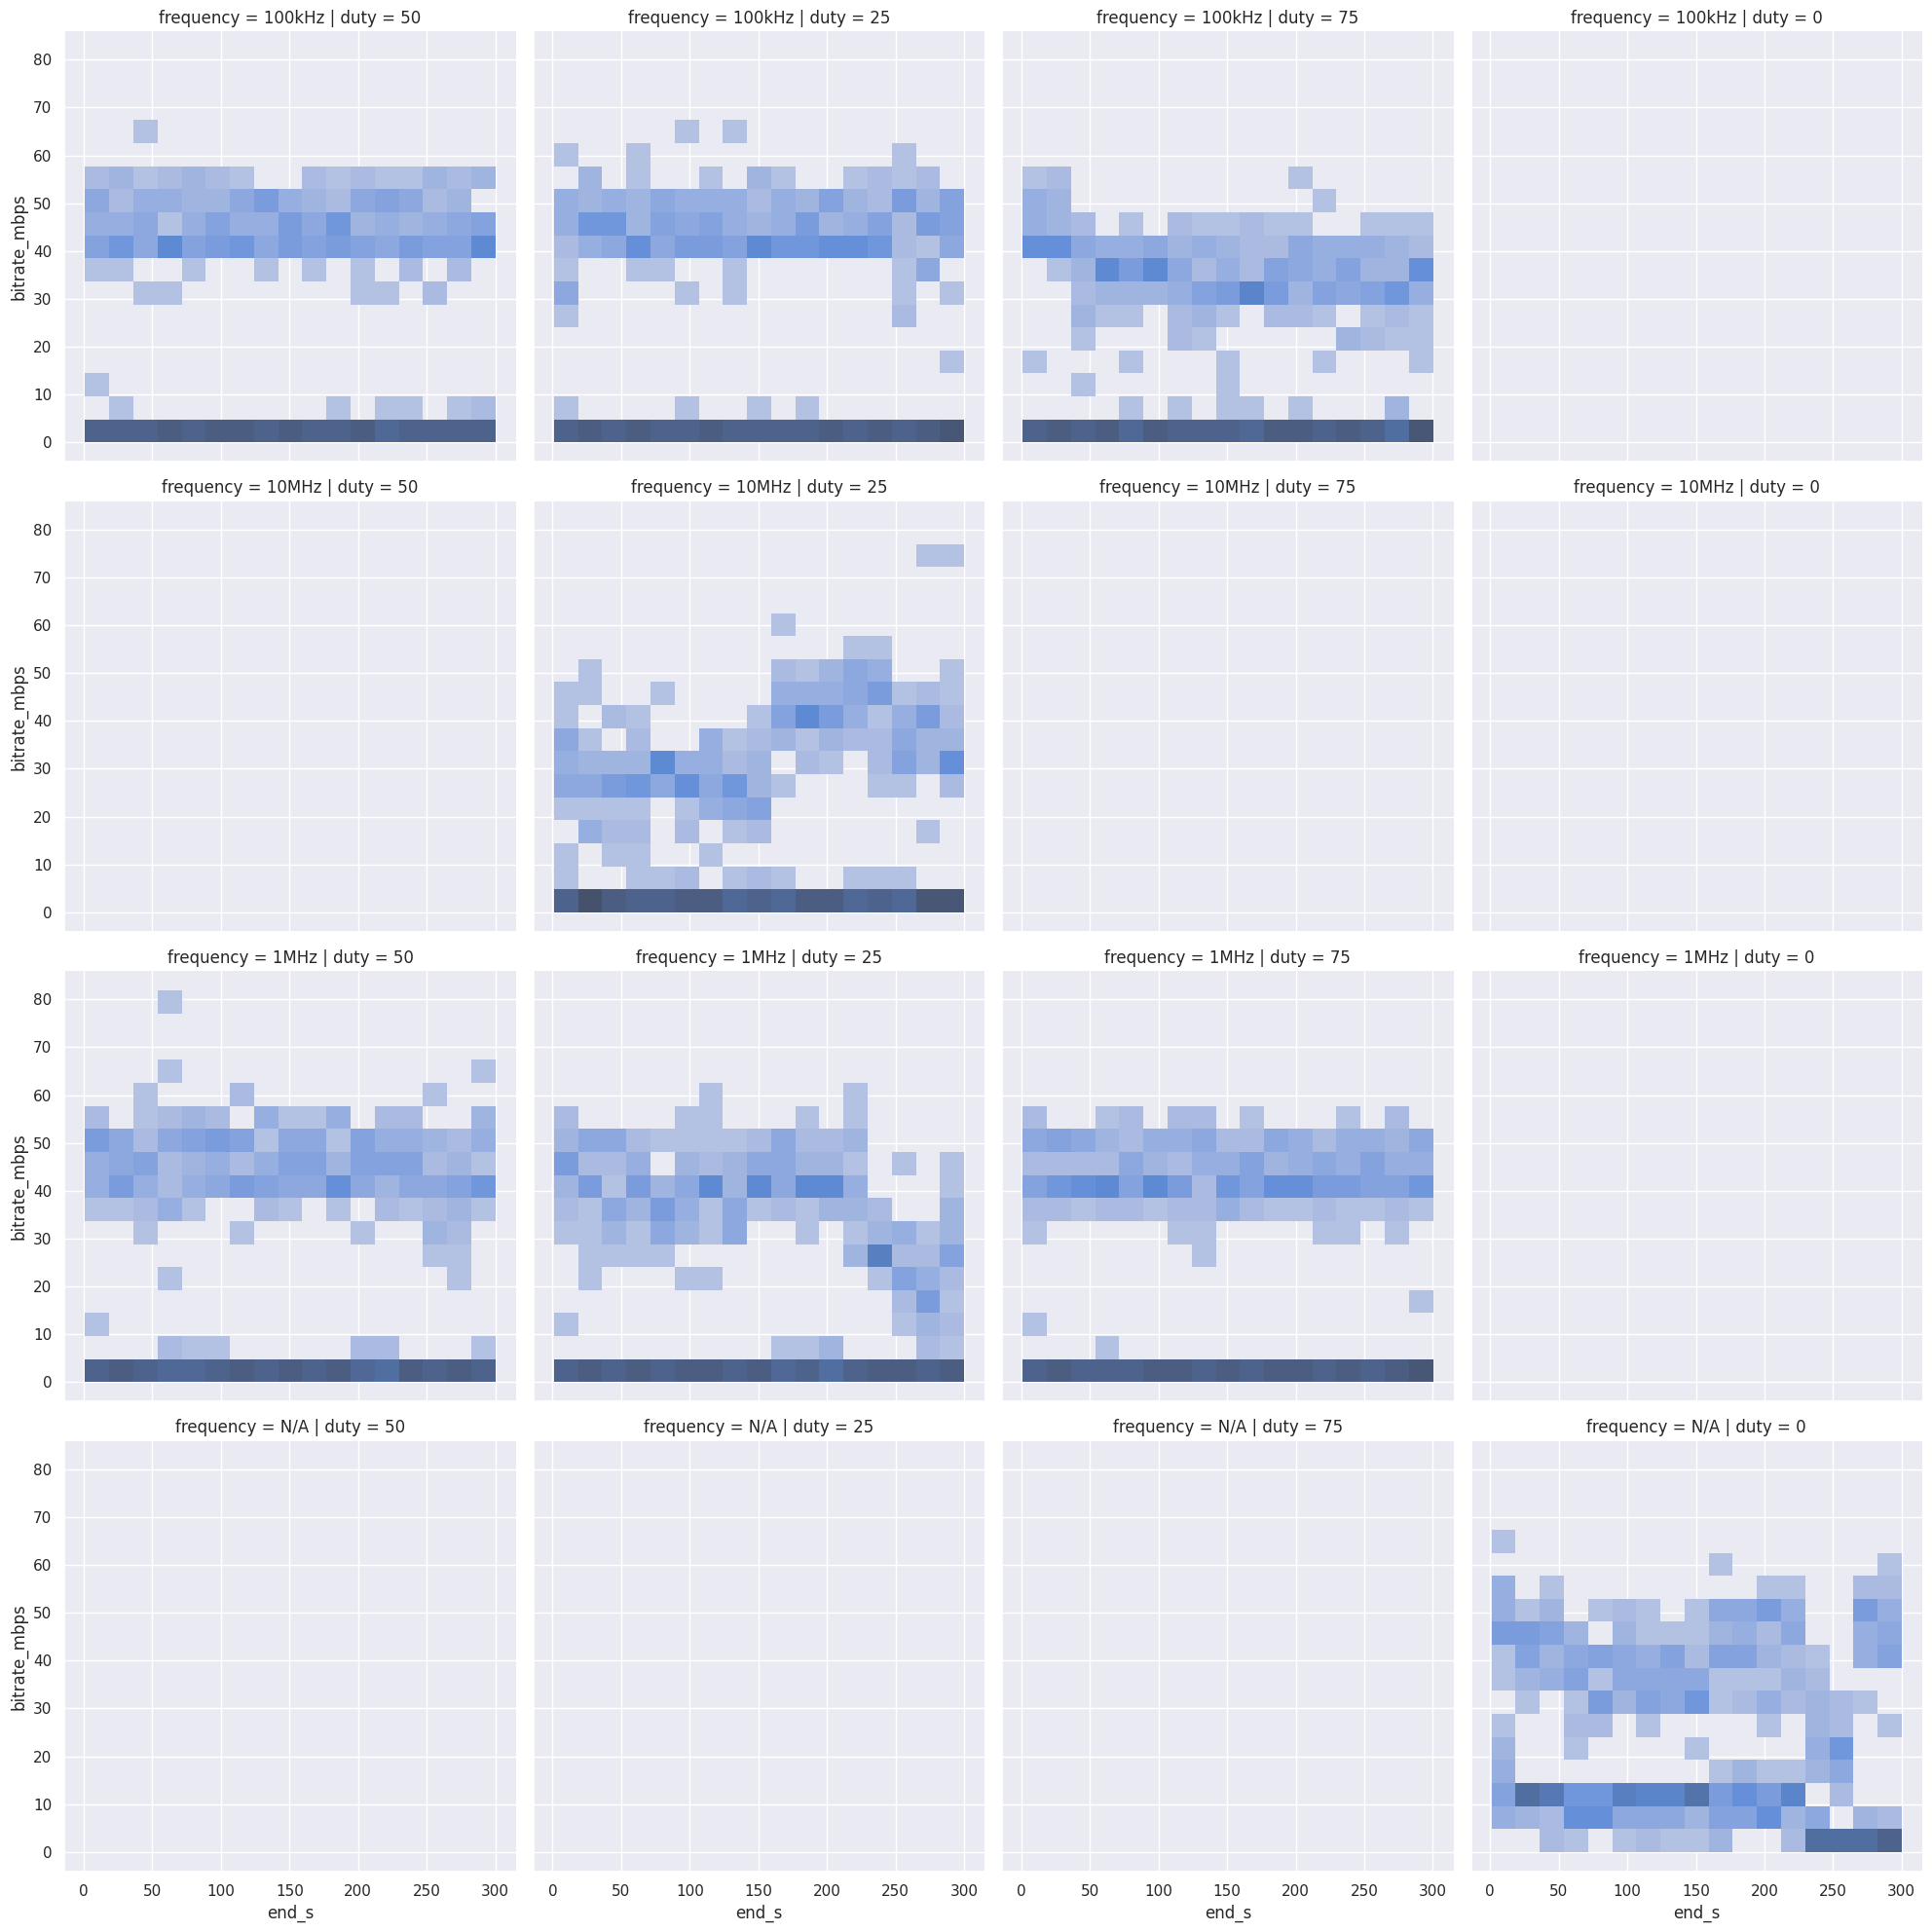

In [37]:
sns.displot(rx_intervals, x='end_s',y='bitrate_mbps',row='frequency',col='duty')

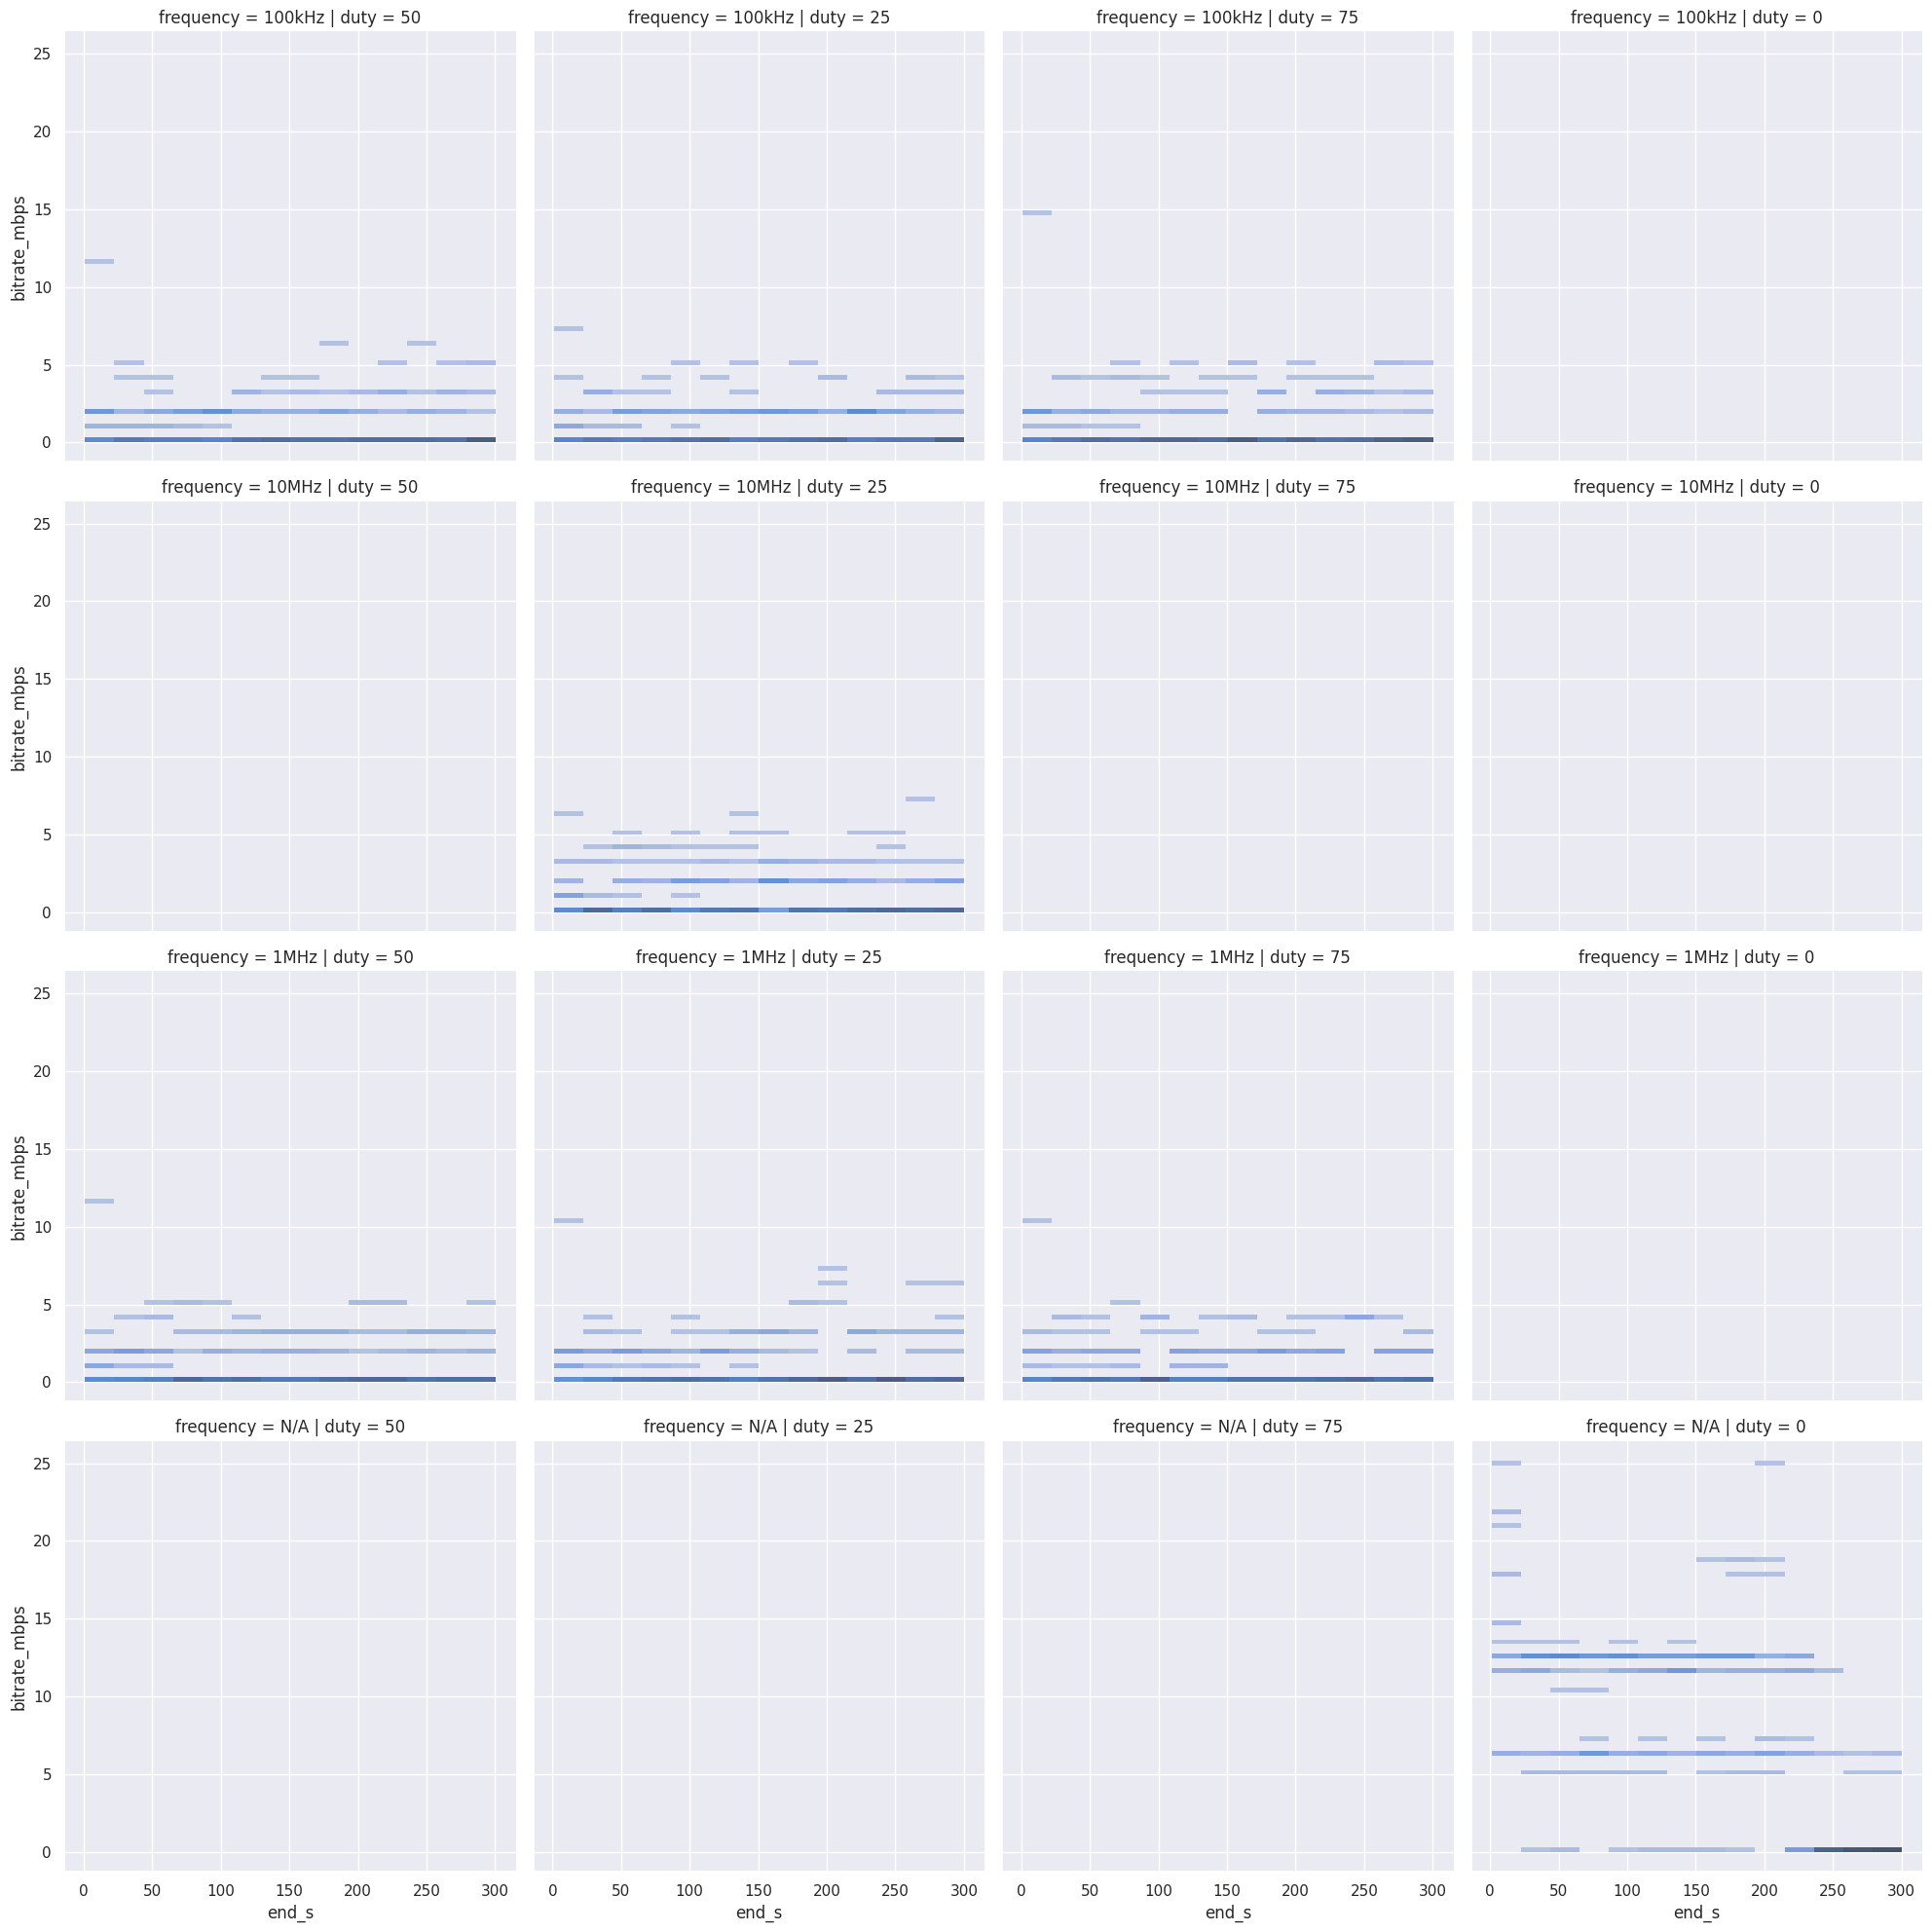

In [38]:
sns.displot(rx_intervals_sender, x='end_s',y='bitrate_mbps',row='frequency',col='duty')

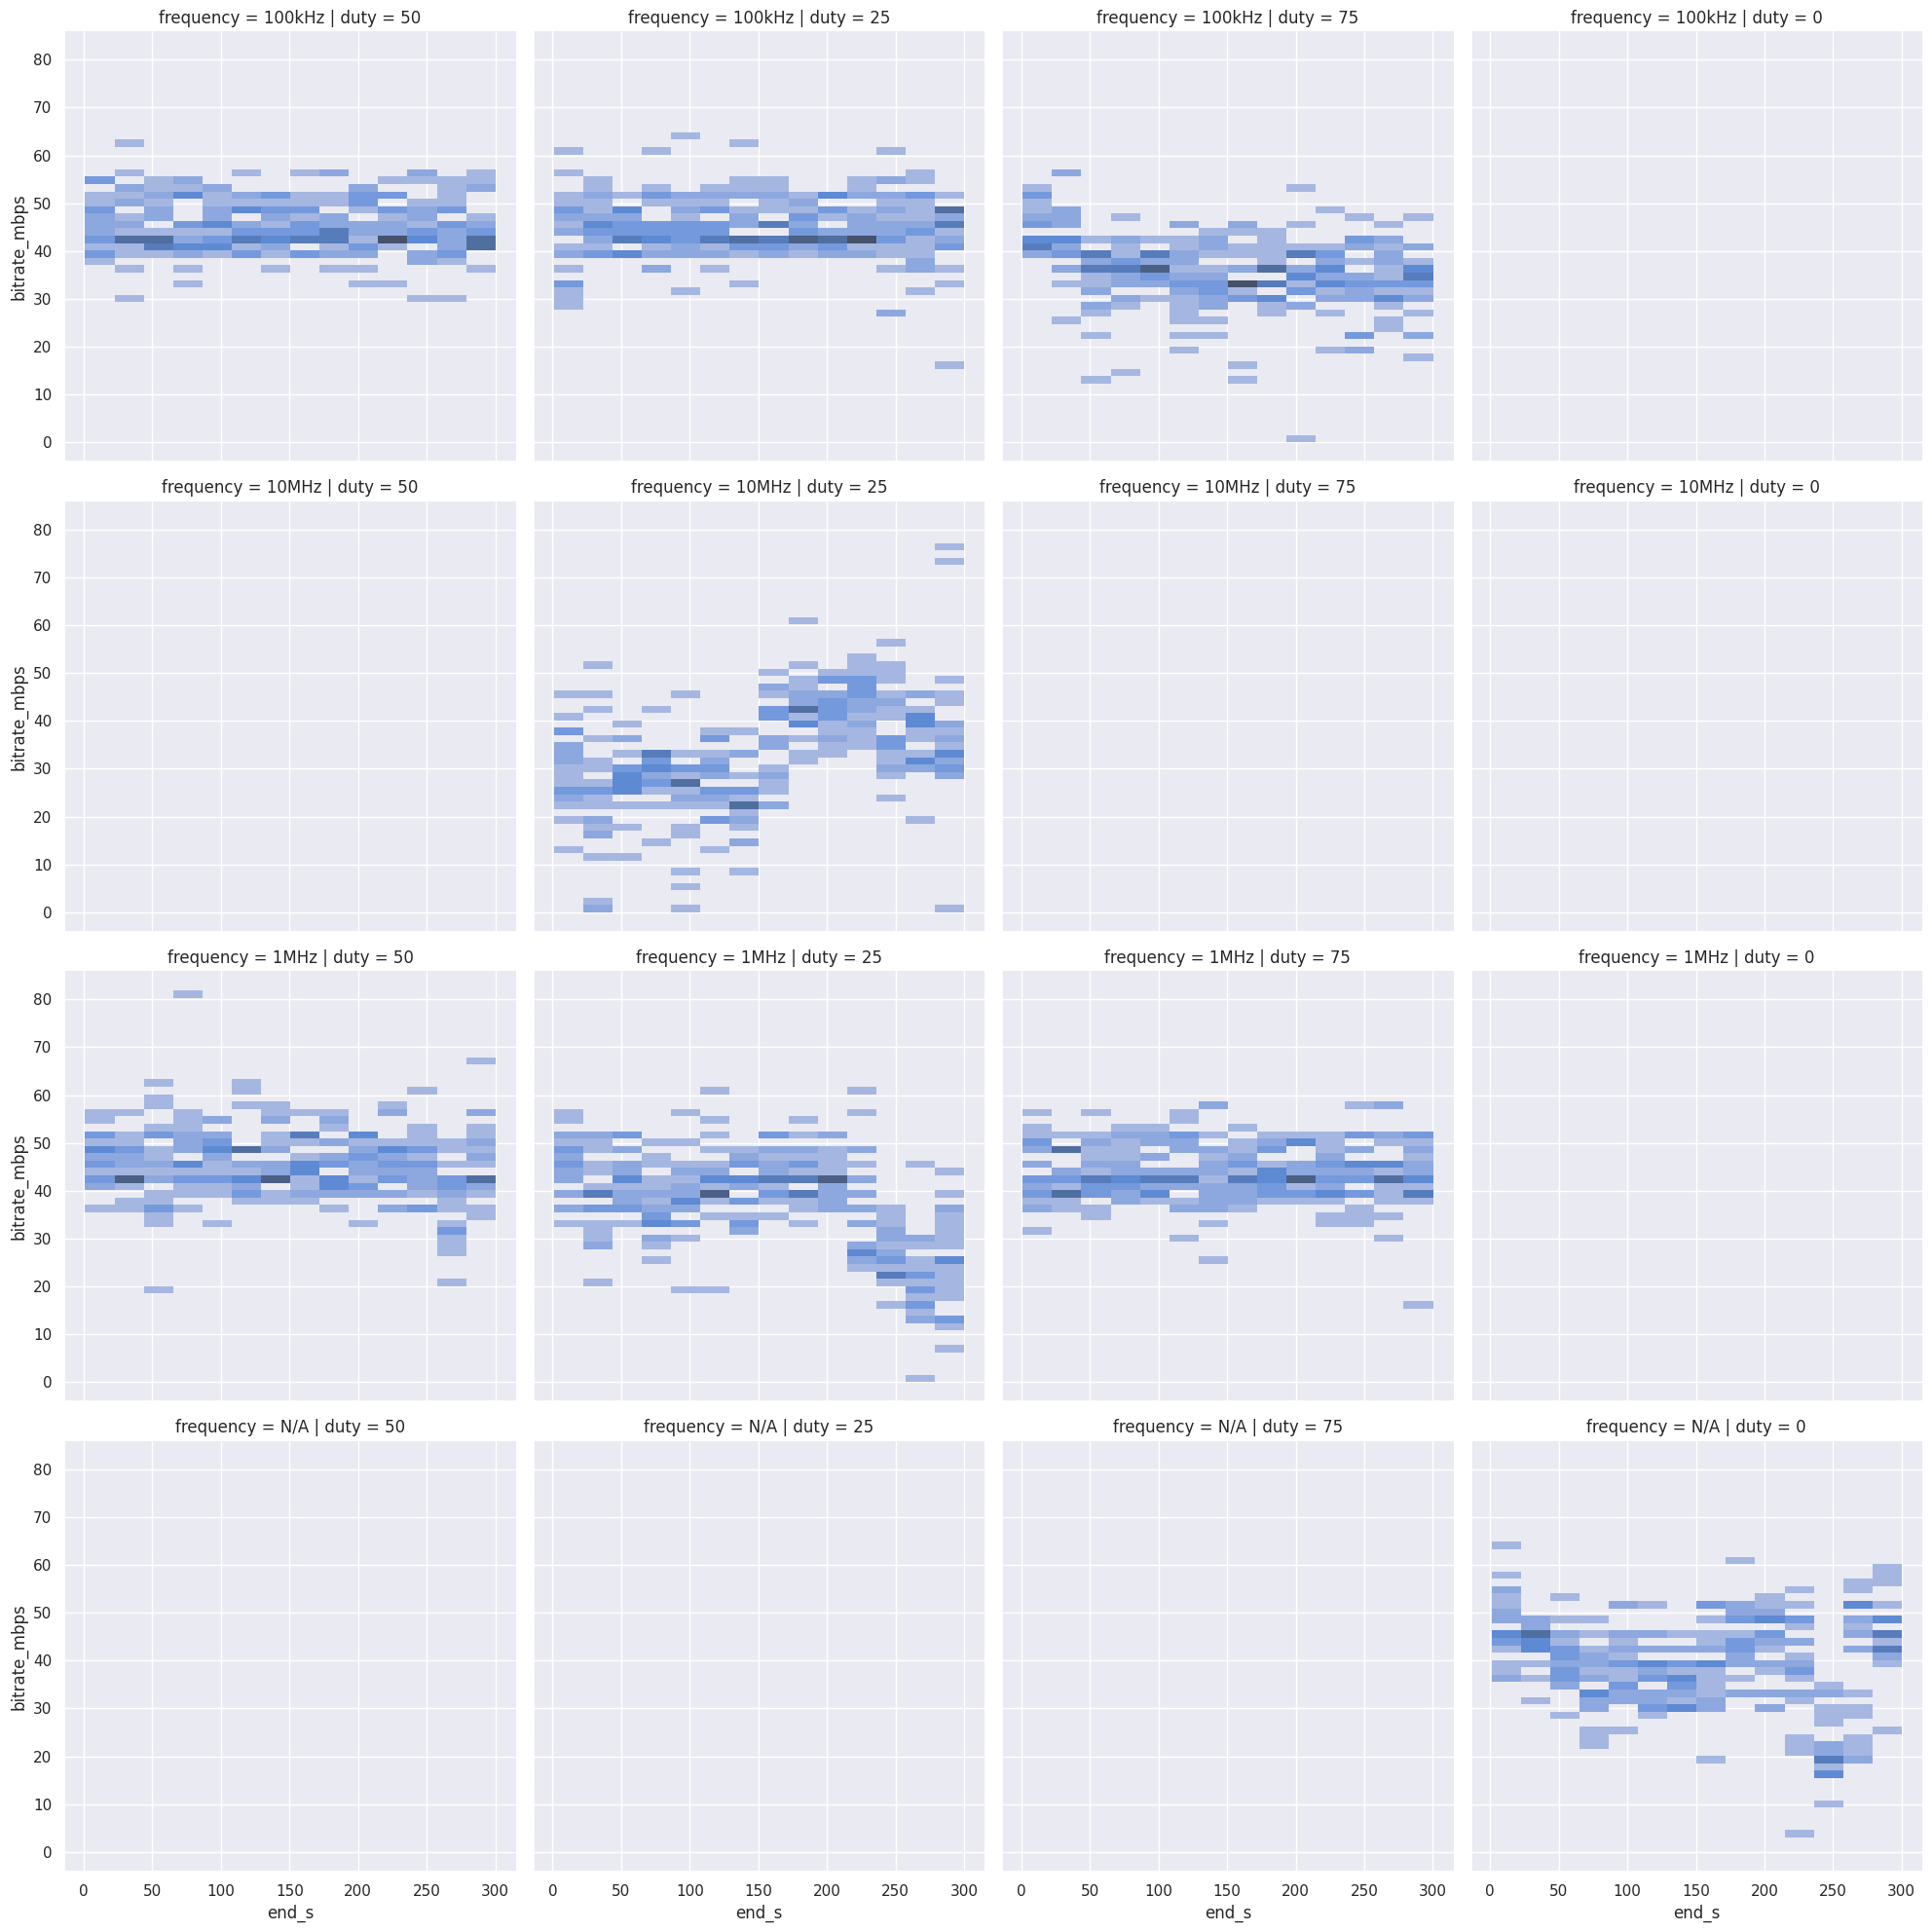

In [39]:
sns.displot(rx_intervals_reciever, x='end_s',y='bitrate_mbps',row='frequency',col='duty')

In [18]:
fig = sns.displot(mid_intervals, x='end_s',y='bitrate_mbps',row='frequency',col='duty')
fig.set_ylabels("Bitrate (Mbps)")
fig.set_xlabels("Time (seconds)")

ValueError: Number of rows must be a positive integer, not 0

<Figure size 0x0 with 0 Axes>

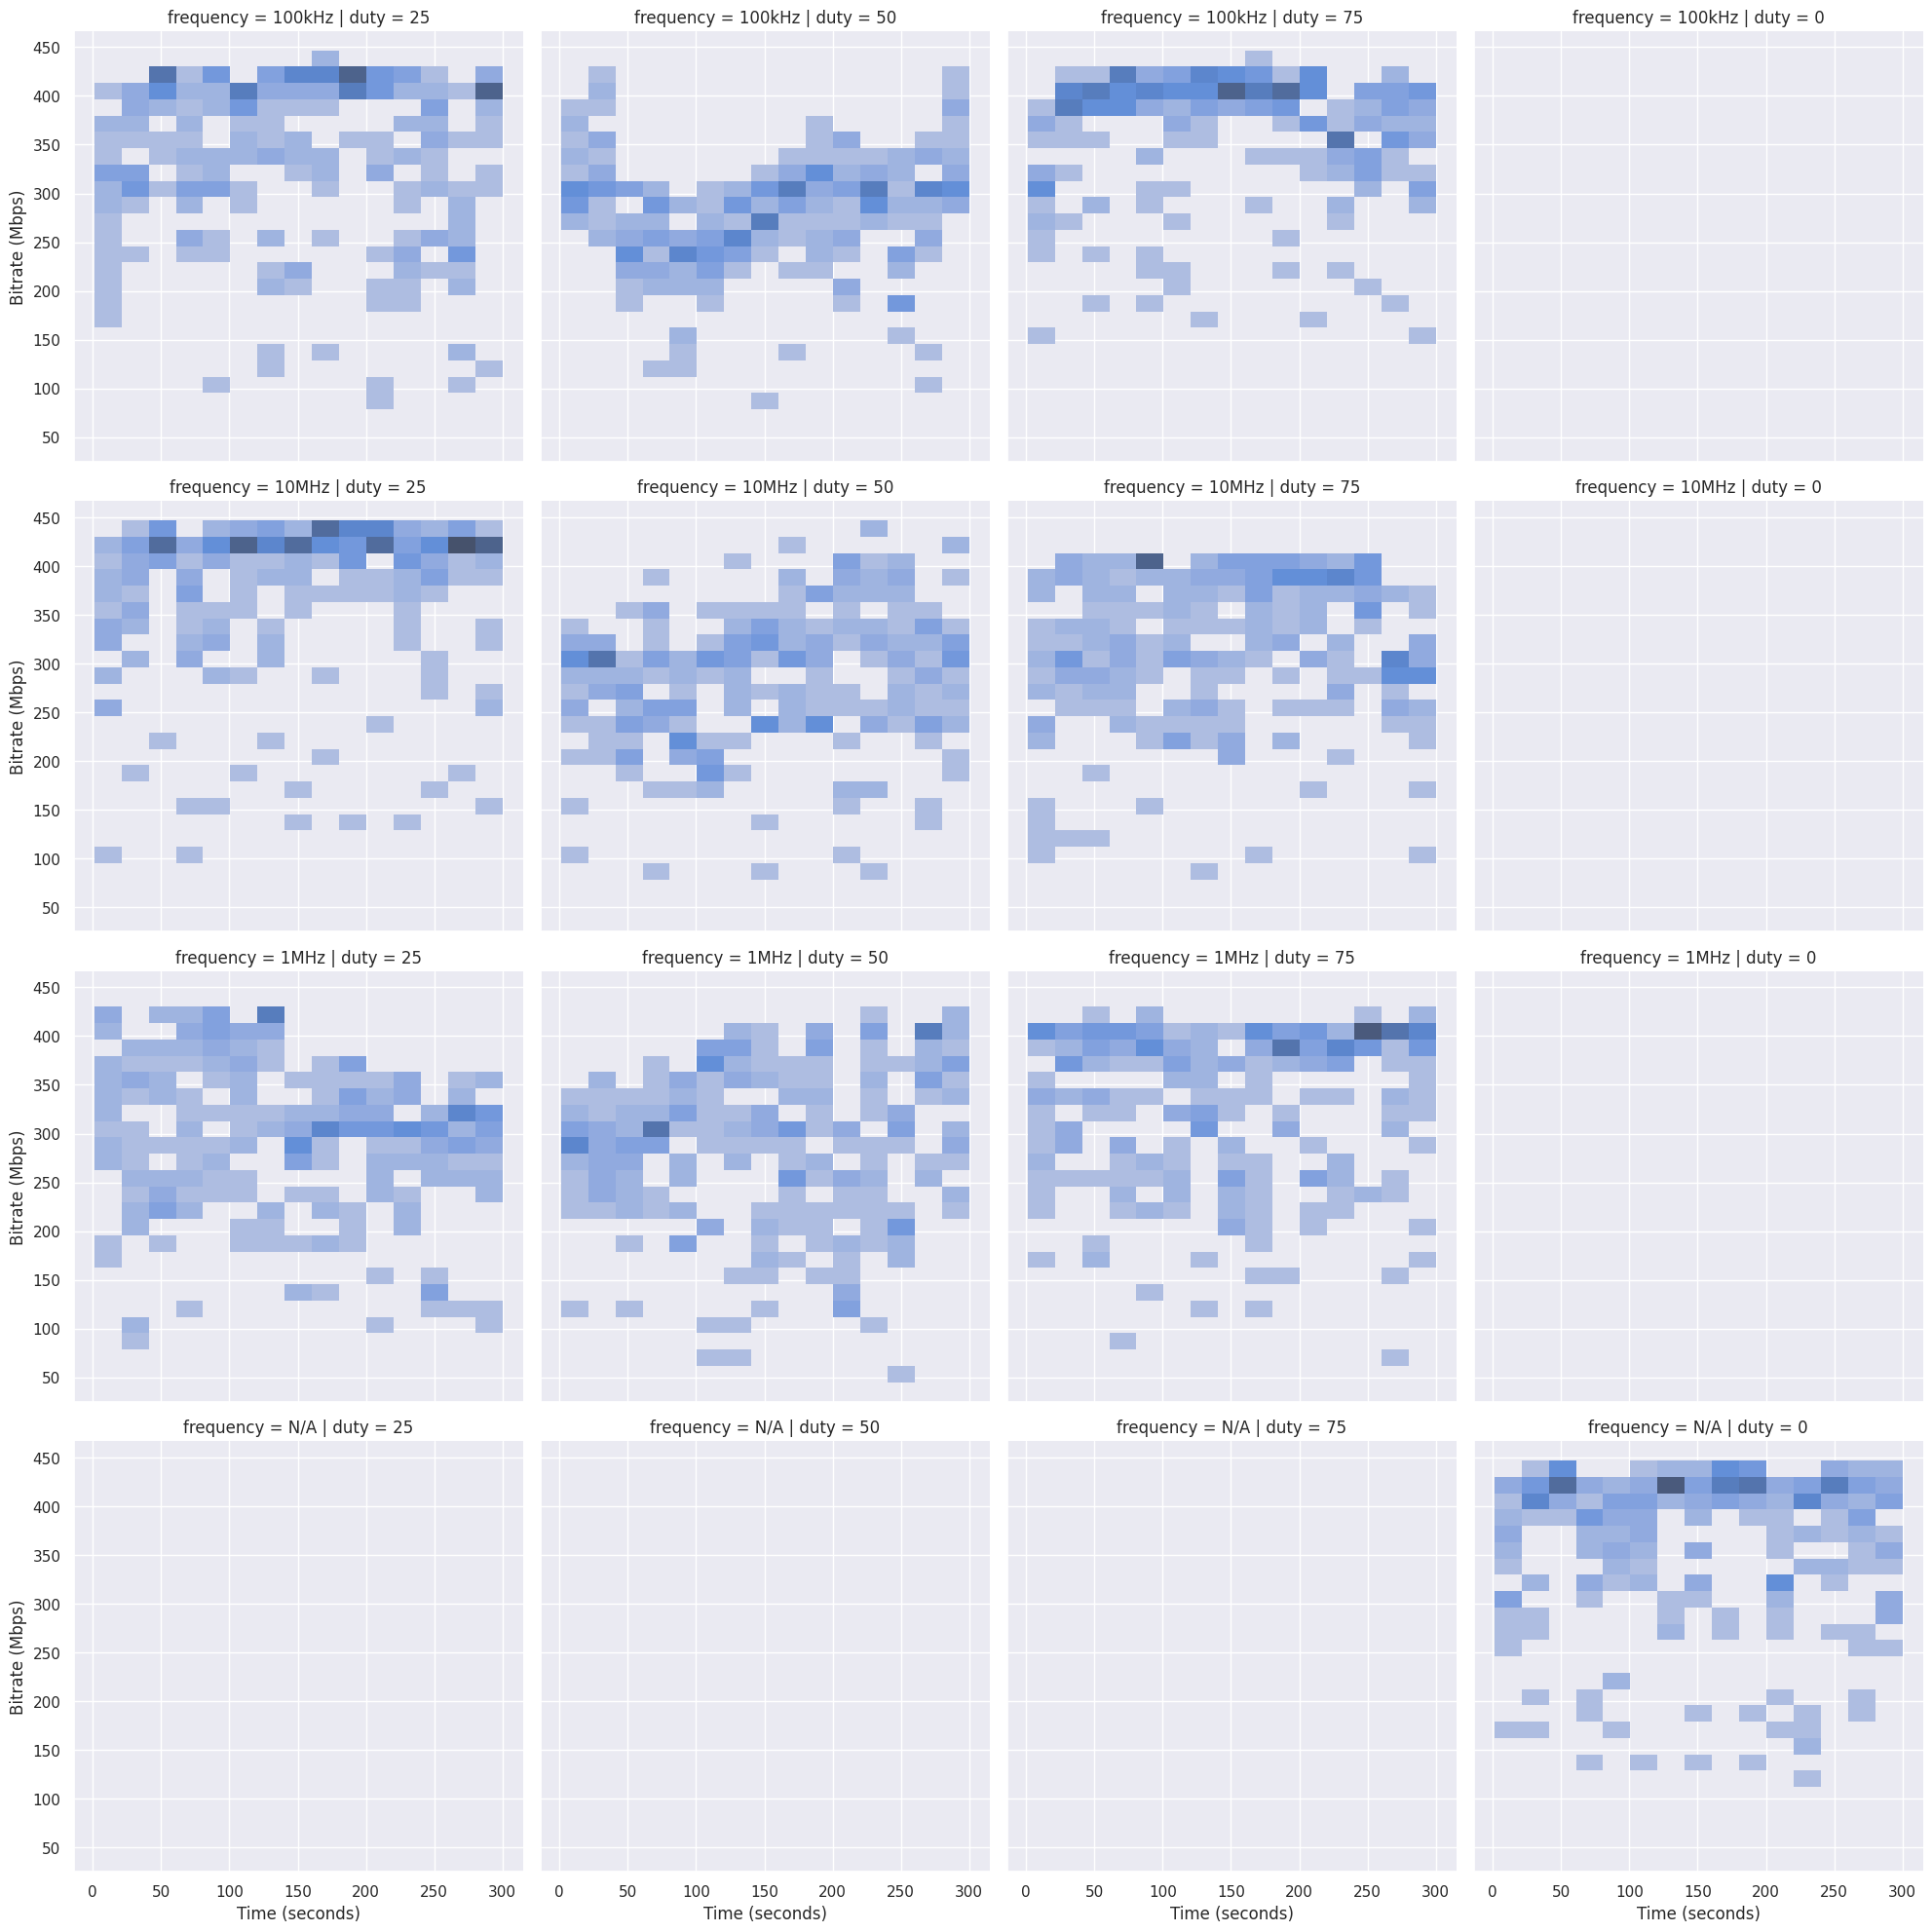

In [ ]:
fig = sns.displot(tx_intervals, x='end_s',y='bitrate_mbps',row='frequency',col='duty')
fig.set_ylabels("Bitrate (Mbps)")
fig.set_xlabels("Time (seconds)")

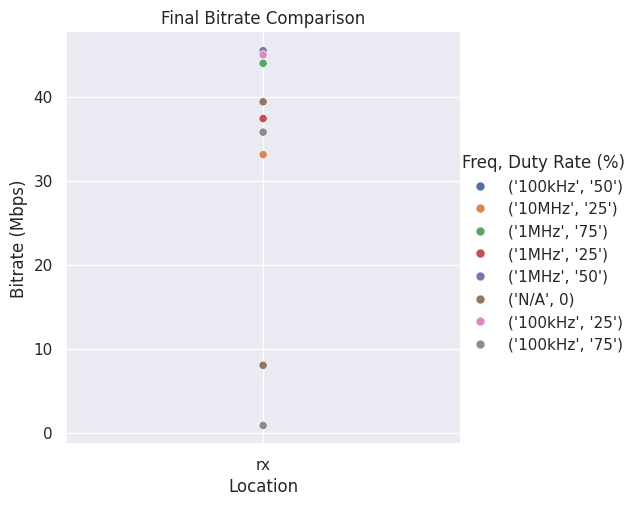

In [17]:
fig = sns.relplot(x='location', y='bitrate_mbps', data=finals,
            hue=finals[['frequency','duty']].apply(tuple, axis=1))

fig.set(xlabel="Location", ylabel="Bitrate (Mbps)", title="Final Bitrate Comparison")
fig._legend.set_title("Freq, Duty Rate (%)")

## Variance comparison

We think that the variance on bitrate and retransmission count could be a decent proxy for the stability of the WiFi communication. 

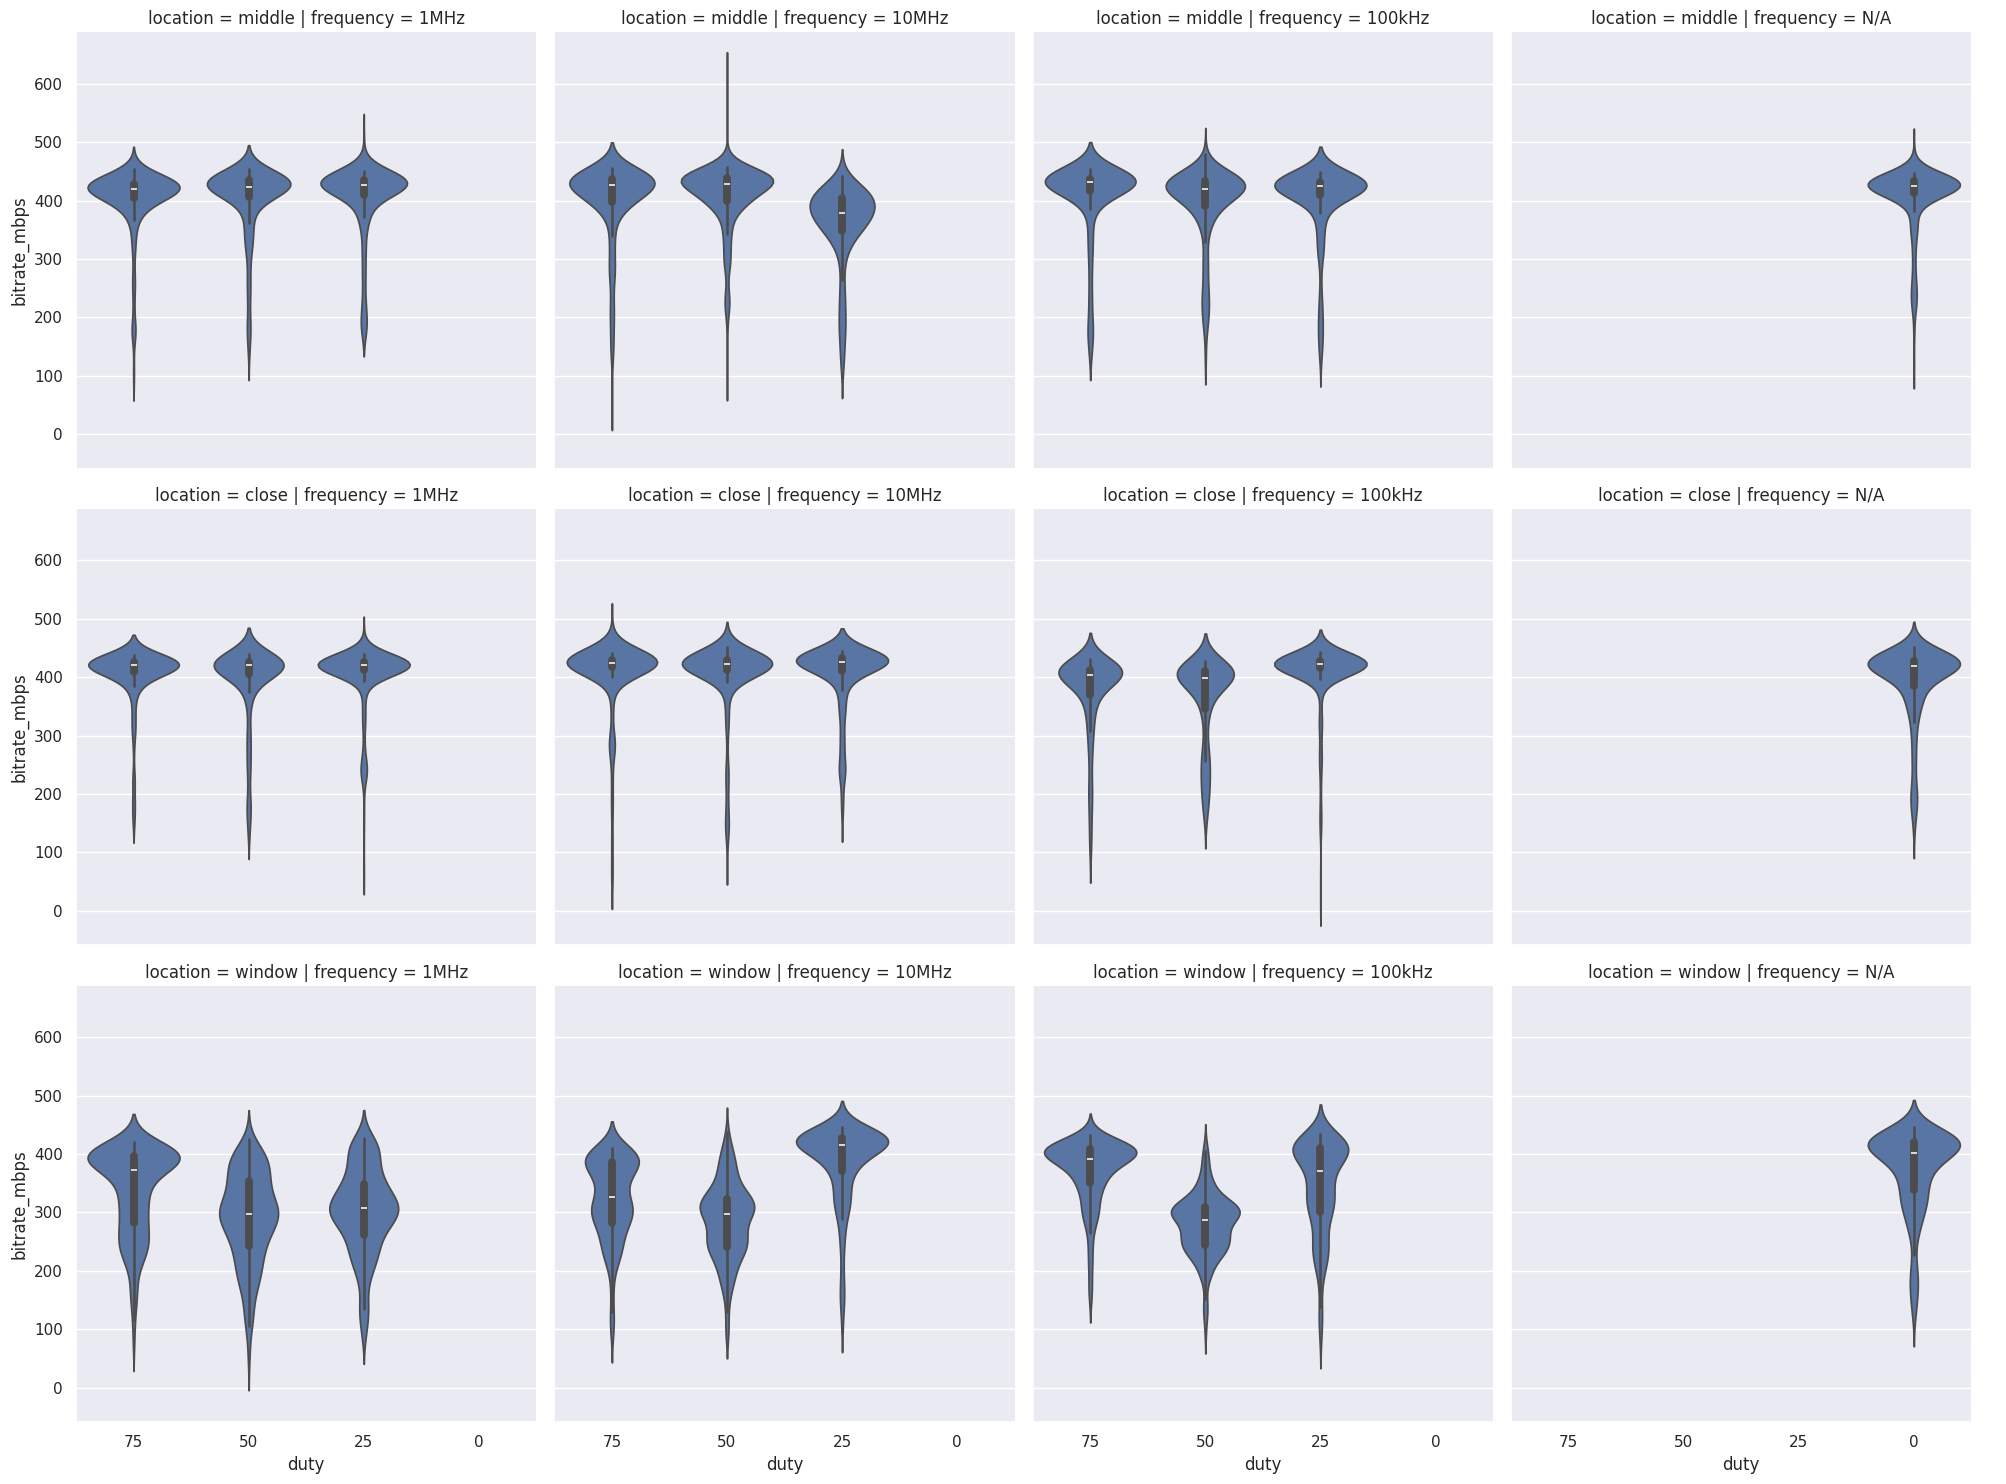

In [78]:
sns.catplot(data=intervals, x='duty', y='bitrate_mbps',
            row='location', col='frequency', kind='violin')

### Heatmap

We also plotted heatmaps for each of the three locations. The colors are for mean bitrate, x is duty cycle and y is frequency. 

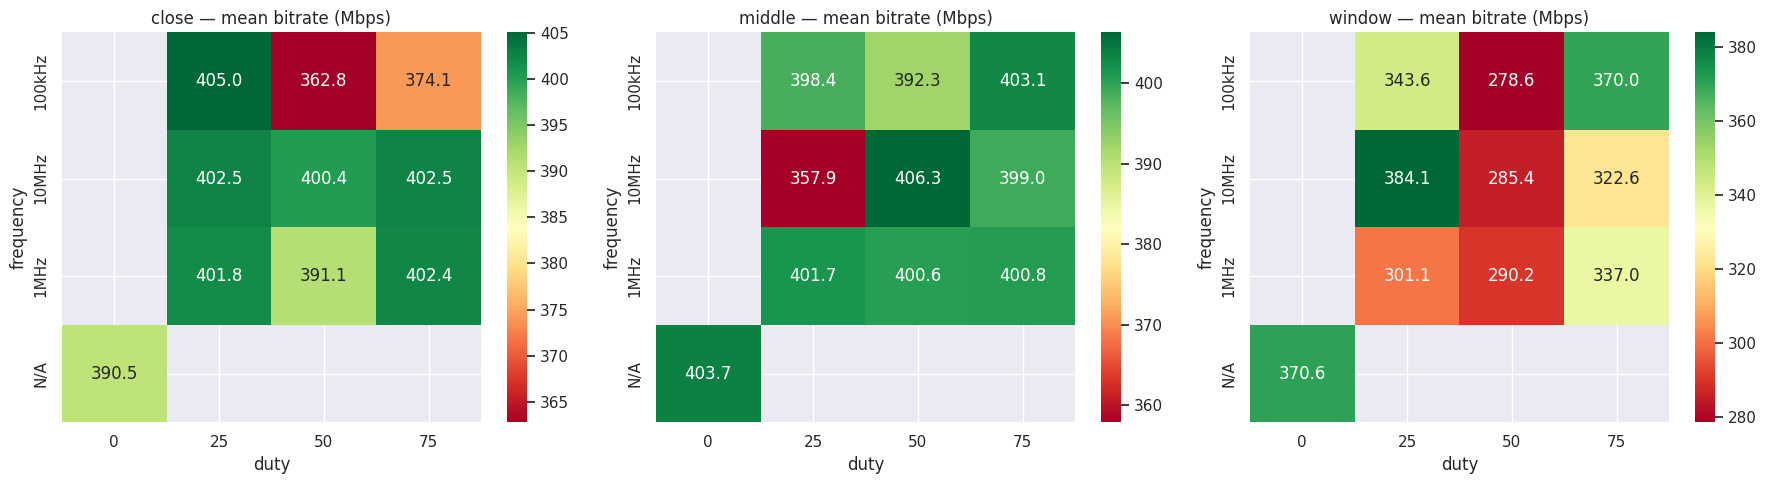

In [90]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

close_pivot = close_intervals.pivot_table(index='frequency', columns='duty',
                                          values='bitrate_mbps', aggfunc='mean')
sns.heatmap(close_pivot, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[0])
axes[0].set_title("close — mean bitrate (Mbps)")

middle_pivot = middle_intervals.pivot_table(index='frequency', columns='duty',
                                            values='bitrate_mbps', aggfunc='mean')
sns.heatmap(middle_pivot, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[1])
axes[1].set_title("middle — mean bitrate (Mbps)")

window_pivot = window_intervals.pivot_table(index='frequency', columns='duty',
                                            values='bitrate_mbps', aggfunc='mean')
sns.heatmap(window_pivot, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[2])
axes[2].set_title("window — mean bitrate (Mbps)")

plt.tight_layout()